# 3D Tetrahedral Sign Check — extending the 2-triangle check to 3D

Companion to [01_vs-central-diff.ipynb](01_vs-central-diff.ipynb). The 2D 2-triangle check splits each quad cell along the TR-BL diagonal into 2 triangles and flags `min(T1, T2) <= 0` as a fold. Central-difference Jacobian determinant misses these folds when its 2Δ stencil averaging cancels their gradient contributions — the canonical bowtie.

This notebook lifts the same idea to 3D. We split each voxel cell along the body diagonal `v0=(0,0,0) → v7=(1,1,1)` into **6 tetrahedra** — the structural analog of "one shared diagonal, minimum-by-shared-diagonal simplex count." Each tet has signed volume `V = (1/6) · (b−a) · ((c−a) × (d−a))`. Per-cell `min(V0, ..., V5) <= 0` flags a fold.

We then run SLSQP under the tet-volume constraint and compare against SLSQP under the existing central-diff Jdet constraint on synthetic 3D bowtie test cases.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_3d, jacobian_det3D
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'THRESHOLD = {THRESHOLD}')

THRESHOLD = 0.01


## Geometry — 6-tet decomposition

A voxel cell has 8 corners indexed by `(z, y, x)` offset:

```
v0 = (0,0,0)   v4 = (1,0,0)
v1 = (0,0,1)   v5 = (1,0,1)
v2 = (0,1,0)   v6 = (1,1,0)
v3 = (0,1,1)   v7 = (1,1,1)
```

The body diagonal `v0 → v7` has Hamming distance 3 in `(z,y,x)` bits, so there are `3! = 6` monotone edge paths from `v0` to `v7`. Each path defines a tetrahedron `(v0, A, B, v7)` where `A` and `B` are the two intermediate corners on the path. All 6 tets share the body diagonal as an edge.

| tet | path | A | B |
|----|----|----|----|
| T0 | x, y, z | v1 | v3 |
| T1 | x, z, y | v1 | v5 |
| T2 | y, x, z | v2 | v3 |
| T3 | y, z, x | v2 | v6 |
| T4 | z, x, y | v4 | v5 |
| T5 | z, y, x | v4 | v6 |

Half of these orderings are even permutations and half odd, so the raw scalar triple product `(b−a)·((c−a)×(d−a))` returns `+1` for some tets and `−1` for others on the unwarped reference cube. We compute the 6 unwarped signs once at notebook startup and apply a fixed per-tet `±1` flip vector so that valid (positive-Jacobian) cells always return strictly positive volumes for all 6 tets.

## Helpers

In [2]:
# 8 cube corners as (z, y, x) offsets, indexed v0..v7 with z*4 + y*2 + x.
CUBE_CORNERS = np.array([
    [0, 0, 0],  # v0
    [0, 0, 1],  # v1
    [0, 1, 0],  # v2
    [0, 1, 1],  # v3
    [1, 0, 0],  # v4
    [1, 0, 1],  # v5
    [1, 1, 0],  # v6
    [1, 1, 1],  # v7
], dtype=np.int8)

# 6-tet body-diagonal decomposition: each row is (v0, A, B, v7) for one of the
# 3! monotone paths from v0 to v7. See the markdown table above.
TET_INDICES = np.array([
    [0, 1, 3, 7],  # T0  path x, y, z
    [0, 1, 5, 7],  # T1  path x, z, y
    [0, 2, 3, 7],  # T2  path y, x, z
    [0, 2, 6, 7],  # T3  path y, z, x
    [0, 4, 5, 7],  # T4  path z, x, y
    [0, 4, 6, 7],  # T5  path z, y, x
], dtype=np.int8)


def warp_corners(phi):
    """Return warped (x, y, z) coordinates of every voxel.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (D, H, W, 3) with last axis = (x, y, z).
    """
    D, H, W = phi.shape[1:]
    zz, yy, xx = np.mgrid[:D, :H, :W]
    dz, dy, dx = phi[0], phi[1], phi[2]
    return np.stack([xx + dx, yy + dy, zz + dz], axis=-1)

In [3]:
# Sanity: identity field warps to identity, shape is right.
phi0 = np.zeros((3, 4, 5, 6))
Wc = warp_corners(phi0)
assert Wc.shape == (4, 5, 6, 3)
assert np.allclose(Wc[2, 3, 4], [4, 3, 2])  # corner (z=2,y=3,x=4) -> (x=4,y=3,z=2)
print('warp_corners OK')

warp_corners OK


In [4]:
def _tet_volumes_unsigned(corners):
    """Compute the 6 raw tet scalar triple products per cell.

    Output shape: (6, D-1, H-1, W-1). Not yet divided by 6 and not yet
    sign-flipped (some entries are negative on the reference cube).
    """
    cell_corners = []
    for (oz, oy, ox) in CUBE_CORNERS:
        cell_corners.append(corners[oz:corners.shape[0] - 1 + oz,
                                     oy:corners.shape[1] - 1 + oy,
                                     ox:corners.shape[2] - 1 + ox])
    cell_corners = np.stack(cell_corners, axis=0)  # (8, D-1, H-1, W-1, 3)

    raw = np.empty((6,) + cell_corners.shape[1:-1], dtype=corners.dtype)
    for ti, (ia, ib, ic, id_) in enumerate(TET_INDICES):
        a = cell_corners[ia]; b = cell_corners[ib]
        c = cell_corners[ic]; d = cell_corners[id_]
        ab = b - a; ac = c - a; ad = d - a
        cx = ac[..., 1] * ad[..., 2] - ac[..., 2] * ad[..., 1]
        cy = ac[..., 2] * ad[..., 0] - ac[..., 0] * ad[..., 2]
        cz = ac[..., 0] * ad[..., 1] - ac[..., 1] * ad[..., 0]
        raw[ti] = ab[..., 0] * cx + ab[..., 1] * cy + ab[..., 2] * cz
    return raw


def _calibrate_sign_flip():
    """One-time per-tet ±1 flip so that the unwarped reference cube returns
    strictly positive volumes for all 6 tets."""
    phi_id = np.zeros((3, 2, 2, 2))
    raw_id = _tet_volumes_unsigned(warp_corners(phi_id))  # (6, 1, 1, 1)
    flip = np.sign(raw_id[:, 0, 0, 0]).astype(np.float64)
    if np.any(flip == 0):
        raise RuntimeError(f'Degenerate identity-field tet volumes: {raw_id.ravel()}')
    return flip


TET_SIGN_FLIP = _calibrate_sign_flip()
print(f'TET_SIGN_FLIP = {TET_SIGN_FLIP}')


def tet_signed_volumes(phi):
    """Per-cell signed volumes of the 6-tet decomposition.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (6, D-1, H-1, W-1). Positive = valid,
    zero = degenerate, negative = flip.
    """
    raw = _tet_volumes_unsigned(warp_corners(phi))
    return TET_SIGN_FLIP[:, None, None, None] * raw / 6.0


def tet_min_per_cell(phi):
    """Worst-of-6 signed volume per cell. Shape (D-1, H-1, W-1)."""
    return tet_signed_volumes(phi).min(axis=0)


def tet_count_negatives(phi):
    """Count of (tet, cell) pairs with signed volume <= 0."""
    return int((tet_signed_volumes(phi) <= 0).sum())

TET_SIGN_FLIP = [ 1. -1. -1.  1.  1. -1.]


In [5]:
# Sanity: identity field gives positive equal volumes for all 6 tets.
phi0 = np.zeros((3, 5, 5, 5))
V = tet_signed_volumes(phi0)
assert V.shape == (6, 4, 4, 4)
assert np.allclose(V, 1.0 / 6.0), f'Expected all 1/6, got min/max = {V.min()}, {V.max()}'

# Sanity: a uniform translation leaves all volumes unchanged.
phi_t = np.zeros((3, 5, 5, 5))
phi_t[0] += 0.3; phi_t[1] -= 0.7; phi_t[2] += 1.4
V_t = tet_signed_volumes(phi_t)
assert np.allclose(V_t, 1.0 / 6.0)

# Sanity: a uniform 2x scaling gives 2^3 / 6 per tet.
phi_s = np.zeros((3, 5, 5, 5))
zz, yy, xx = np.mgrid[:5, :5, :5]
phi_s[0] = zz; phi_s[1] = yy; phi_s[2] = xx  # corners (z,y,x) -> (2z,2y,2x)
V_s = tet_signed_volumes(phi_s)
assert np.allclose(V_s, 8.0 / 6.0), f'Expected 8/6, got min={V_s.min()}, max={V_s.max()}'

# Sanity: a single-voxel inversion folds a cell.
phi_fold = np.zeros((3, 3, 3, 3))
phi_fold[2, 1, 1, 1] = -2.5  # large -dx pulls centre voxel past its left neighbour
V_f = tet_signed_volumes(phi_fold)
assert (V_f <= 0).any(), 'Expected at least one negative tet for the inversion test'

print(f'Identity volume       : {V[0,0,0,0]:.6f}  (expected 1/6 = {1/6:.6f})')
print(f'Uniform 2x scaling    : {V_s[0,0,0,0]:.6f}  (expected 8/6 = {8/6:.6f})')
print(f'Inversion test n_neg  : {int((V_f <= 0).sum())}')
print('tet_signed_volumes OK')

Identity volume       : 0.166667  (expected 1/6 = 0.166667)
Uniform 2x scaling    : 1.333333  (expected 8/6 = 1.333333)
Inversion test n_neg  : 6
tet_signed_volumes OK


In [6]:
# Variable packing follows dvfopt.core.solver3d._full_grid_step_3d:
# phi_flat = [dx_flat, dy_flat, dz_flat].

def tet_constraint_flat(phi_flat, grid_shape):
    """Flat 6 * (D-1) * (H-1) * (W-1) tet signed volumes for SLSQP."""
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    phi = np.stack([dz, dy, dx])
    return tet_signed_volumes(phi).flatten()


def jdet_constraint_flat(phi_flat, grid_shape):
    """Flat central-diff Jdet over the full grid (baseline S-CD constraint)."""
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    return _numpy_jdet_3d(dz, dy, dx).flatten()


def pack_phi(phi):
    """phi (3, D, H, W) -> flat [dx, dy, dz]."""
    return np.concatenate([phi[2].flatten(), phi[1].flatten(), phi[0].flatten()])


def unpack_phi(phi_flat, grid_shape):
    """flat [dx, dy, dz] -> phi (3, D, H, W)."""
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    return np.stack([dz, dy, dx])

In [7]:
rng = np.random.default_rng(0)
phi_rand = rng.standard_normal((3, 4, 5, 6))
flat = pack_phi(phi_rand)
phi_back = unpack_phi(flat, (4, 5, 6))
assert np.allclose(phi_back, phi_rand), 'pack/unpack roundtrip failed'

c_flat = tet_constraint_flat(flat, (4, 5, 6))
c_array = tet_signed_volumes(phi_rand).flatten()
assert np.allclose(c_flat, c_array), 'flat vs array form disagree'
assert c_flat.shape == (6 * 3 * 4 * 5,)

print(f'pack/unpack and constraint helpers OK  '
      f'(flat shape {flat.shape}, constraint shape {c_flat.shape})')

pack/unpack and constraint helpers OK  (flat shape (360,), constraint shape (360,))


## Test case 1 — 3D x-axis bowtie

The textbook 2D bowtie from `01_vs-central-diff.ipynb` (`dx[3,3]=+1.2, dx[3,4]=−1.2`) lifted to 3D by placing it in the middle z-slice of a 7×7×7 zero field.

Expected: central-diff Jdet stays all-positive (it's still a 2Δ stencil failure), but the tet check flags at least one cell with a negative tet volume.

In [8]:
def make_bowtie_x(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy, cx]     = +1.2  # dx
    phi[2, cz, cy, cx + 1] = -1.2
    return phi


phi_bx = make_bowtie_x()
j_bx = jacobian_det3D(phi_bx)
v_bx = tet_signed_volumes(phi_bx)

print('case 1 — 3D x-axis bowtie  (7x7x7)')
print(f'  central-diff Jdet  : min={j_bx.min():+.4f}  max={j_bx.max():+.4f}  n_neg={int((j_bx <= 0).sum())}')
print(f'  tet-volume check   : min={v_bx.min():+.4f}  max={v_bx.max():+.4f}  n_neg={int((v_bx <= 0).sum())}')
print(f'  cells with any neg tet: {int((v_bx.min(axis=0) <= 0).sum())}')

per_tet_neg = (v_bx <= 0).reshape(6, -1).sum(axis=1)
print(f'  per-tet neg counts  : {per_tet_neg.tolist()}  (T0..T5)')

case 1 — 3D x-axis bowtie  (7x7x7)
  central-diff Jdet  : min=+0.4000  max=+1.6000  n_neg=0
  tet-volume check   : min=-0.2333  max=+0.3667  n_neg=6
  cells with any neg tet: 4
  per-tet neg counts  : [1, 1, 1, 1, 1, 1]  (T0..T5)


In [9]:
# Canonical disagreement between central-diff and the tet check.
assert int((j_bx <= 0).sum()) == 0, 'central-diff should not detect this fold'
assert int((v_bx <= 0).sum()) >= 1, 'tet check must catch at least one flip'
print('case 1 disagreement confirmed: CD says clean, tet says folded')

case 1 disagreement confirmed: CD says clean, tet says folded


## Test cases 2 and 3 — z-axis bowtie + xy diagonal swap

**Case 2.** Same bowtie pattern, axis-rotated to z. Validates the 6-tet check is sensitive across all three axes (the body-diagonal choice could in principle bias detection toward folds aligned with one axis — running the same pattern on each axis tests that).

**Case 3.** A multi-axis fold: opposing displacements in both `dx` and `dy` between two adjacent y-rows. The fold is no longer aligned to a single axis; central-diff often still misses it, and we expect a different per-tet flip pattern.

In [10]:
def make_bowtie_z(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[0, cz,     cy, cx] = +1.2  # dz
    phi[0, cz + 1, cy, cx] = -1.2
    return phi


def make_xy_diagonal(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy,     cx] = +0.8;  phi[1, cz, cy,     cx] = +0.8
    phi[2, cz, cy + 1, cx] = -0.8;  phi[1, cz, cy + 1, cx] = -0.8
    return phi


CASES = [
    ('case 1 — x-axis bowtie',    make_bowtie_x()),
    ('case 2 — z-axis bowtie',    make_bowtie_z()),
    ('case 3 — xy diagonal swap', make_xy_diagonal()),
]

print(f"{'case':<32s}  {'CD min':>9s}  {'CD n_neg':>9s}  "
      f"{'tet min':>9s}  {'tet n_neg':>10s}  {'cells_folded':>13s}")
print('-' * 95)
for name, phi in CASES:
    j = jacobian_det3D(phi)
    v = tet_signed_volumes(phi)
    cells_folded = int((v.min(axis=0) <= 0).sum())
    print(f'{name:<32s}  {j.min():+9.4f}  {int((j<=0).sum()):>9d}  '
          f'{v.min():+9.4f}  {int((v<=0).sum()):>10d}  {cells_folded:>13d}')

case                                 CD min   CD n_neg    tet min   tet n_neg   cells_folded
-----------------------------------------------------------------------------------------------
case 1 — x-axis bowtie              +0.4000          0    -0.2333           6              4
case 2 — z-axis bowtie              +0.4000          0    -0.2333           6              4
case 3 — xy diagonal swap           +0.6000          0    -0.1000           2              2


In [11]:
for name, phi in CASES:
    v = tet_signed_volumes(phi)
    assert (v <= 0).any(), f'{name} produced no flip — case is invalid'
print('all 3 cases produce at least one flipped tet')

all 3 cases produce at least one flipped tet


## SLSQP correction — central-diff (S-CD) vs tet-volume (S-TET) constraint

Two solver runs per case:

- **S-CD** — full-grid SLSQP with `_numpy_jdet_3d ≥ THRESHOLD`. This is the existing approach in `dvfopt.core.solver3d._full_grid_step_3d`.
- **S-TET** — full-grid SLSQP with all 6 per-cell tet signed volumes `≥ THRESHOLD`.

Both use the L2 objective (`objective_euc`) starting from the folded `phi`.

The tet constraint vector for a `D × H × W` grid has length `6 · (D-1) · (H-1) · (W-1)`. On 7³ this is `6 · 6³ = 1296` constraints — manageable for SLSQP.

### S-TET constraints in detail

The optimisation solved for each test case is

$$
\min_{\phi}\; \tfrac{1}{2}\,\lVert \phi - \phi_{0} \rVert_{2}^{2}
\qquad \text{subject to}\qquad
V_{t}(c;\,\phi) \;\ge\; \tau
\quad \text{for every cell } c \text{ and every tet } t.
$$

**Variables.** $\phi$ is the flattened displacement field of length $3 \cdot D \cdot H \cdot W$, packed as $[\,\mathrm{dx}\,\mid\,\mathrm{dy}\,\mid\,\mathrm{dz}\,]$ (matching `dvfopt.core.solver3d._full_grid_step_3d`). $\phi_{0}$ is the folded input. $\tau = \mathtt{THRESHOLD} = 0.01$.

**Per-tet signed volume.** Cell $c$ has integer origin $(c_z,c_y,c_x)$ and 8 corners $p_{i} = (c_z+\delta z_i,\,c_y+\delta y_i,\,c_x+\delta x_i)$ for $i \in \{0,\dots,7\}$ from `CUBE_CORNERS`. The warped position of corner $i$ is

$$
\mathbf{x}_{i}^{\mathrm{w}}(\phi) \;=\; \bigl(\,c_x + \delta x_i + \mathrm{dx}[p_i],\ \ c_y + \delta y_i + \mathrm{dy}[p_i],\ \ c_z + \delta z_i + \mathrm{dz}[p_i]\,\bigr).
$$

For tet $t \in \{T_0,\dots,T_5\}$ with vertex indices $(i_a, i_b, i_c, i_d)$ from `TET_INDICES`, write the warped corners as $\mathbf{a},\mathbf{b},\mathbf{c},\mathbf{d}$ for short. The signed volume is

$$
V_{t}(c;\,\phi) \;=\; \frac{s_{t}}{6}\;
\bigl(\mathbf{b}-\mathbf{a}\bigr) \,\cdot\, \bigl[\,(\mathbf{c}-\mathbf{a})\times(\mathbf{d}-\mathbf{a})\,\bigr].
$$

The factor $s_{t} \in \{+1,-1\}$ is the entry of `TET_SIGN_FLIP`. It is needed because half of the six monotone-path orderings $(v_0,A,B,v_7)$ are even permutations of the cube's vertices and half are odd, so the raw scalar triple product is positive on three tets of the unwarped cube and negative on three. Calibrating $s$ once on the identity field (`_calibrate_sign_flip`) makes every $V_t$ unambiguously *positive on a valid cell*, so the single uniform inequality $V_t \ge \tau$ correctly excludes folds for all six tets.

**One constraint per (cell, tet).** Stacking over every interior cell of the grid and every tet of its decomposition gives a vector-valued constraint of length

$$
N_{\text{constr}} \;=\; 6 \,\cdot\, (D-1)(H-1)(W-1).
$$

For the $7^{3}$ test cases this is $6 \cdot 6^{3} = 1296$ scalar constraints over $3 \cdot 7^{3} = 1029$ variables. (The 2D analog in `triangle_sign_constraint` uses $2\cdot(H-1)(W-1)$ constraints — same shape, one diagonal per cell, two simplices per cell.)

**Why this is well-posed for SLSQP.** Each $V_t$ is a polynomial of degree 3 in the displacement components — smooth and infinitely differentiable. SLSQP's quasi-Newton update needs only the constraint values and a Jacobian; we hand it the values via `tet_constraint_flat` and let scipy estimate the Jacobian by finite differences (the small problem size makes this fine; promoting this to `iterative_3d` for production-scale grids would want an analytic Jacobian, mirroring `gradients3d.jdet_constraint_jacobian_3d`).

**Geometric meaning of the constraint.**

| sign of $V_t$ | what it means geometrically |
|---|---|
| $V_t \ge \tau$ | tet is non-degenerate and oriented like the unwarped reference (valid). |
| $0 \le V_t < \tau$ | tet is valid but thin — within the safety margin near collapse. |
| $V_t = 0$ | tet has collapsed to a plane (4 coplanar corners). |
| $V_t < 0$ | tet has *inverted* — its 4 warped corners trace the opposite handedness from the reference. This is the local 3D analog of the bowtie. |

A cell is fold-free iff all 6 of its tets satisfy $V_t \ge \tau$. The S-TET solver makes this hold simultaneously for every cell. Contrast S-CD, which imposes *one* central-difference Jdet $\ge \tau$ per voxel — an averaged 9-partial quantity that can stay positive while individual tets in the same cell are inverted, exactly the failure mode the per-tet constraint is designed to close.

In [12]:
def run_slsqp(phi_anchor, constraint_kind, max_iter=200, threshold=THRESHOLD):
    """Full-grid SLSQP with either central-diff or tet-volume constraints."""
    grid_shape = phi_anchor.shape[1:]
    z0 = pack_phi(phi_anchor)

    if constraint_kind == 'cd':
        constr = NonlinearConstraint(
            lambda z: jdet_constraint_flat(z, grid_shape),
            lb=threshold, ub=np.inf,
        )
    elif constraint_kind == 'tet':
        constr = NonlinearConstraint(
            lambda z: tet_constraint_flat(z, grid_shape),
            lb=threshold, ub=np.inf,
        )
    else:
        raise ValueError(constraint_kind)

    t0 = time.time()
    res = minimize(
        lambda z: objective_euc(z, z0),
        z0.copy(), jac=True, method='SLSQP',
        constraints=[constr],
        options={'maxiter': max_iter, 'disp': False},
    )
    elapsed = time.time() - t0
    phi_out = unpack_phi(res.x, grid_shape)
    j_out = jacobian_det3D(phi_out)
    v_out = tet_signed_volumes(phi_out)
    return {
        'phi': phi_out,
        'l2': float(np.linalg.norm(phi_out - phi_anchor)),
        'n_neg_cd':  int((j_out <= 0).sum()),
        'n_neg_tet': int((v_out <= 0).sum()),
        'min_cd':  float(j_out.min()),
        'min_tet': float(v_out.min()),
        'nit': res.nit,
        't': elapsed,
        'success': bool(res.success),
        'status': int(res.status),
    }


print('Running SLSQP on each case (this takes ~30s total on 7^3)...')
slsqp_results = {}
for name, phi in CASES:
    print(f'  {name}', flush=True)
    r_cd  = run_slsqp(phi, 'cd',  max_iter=200)
    print(f'    S-CD : nit={r_cd["nit"]:3d}  t={r_cd["t"]:5.2f}s  '
          f'L2={r_cd["l2"]:6.3f}  n_neg_cd={r_cd["n_neg_cd"]:3d}  '
          f'n_neg_tet={r_cd["n_neg_tet"]:3d}  min_tet={r_cd["min_tet"]:+.3f}  ok={r_cd["success"]}',
          flush=True)
    r_tet = run_slsqp(phi, 'tet', max_iter=200)
    print(f'    S-TET: nit={r_tet["nit"]:3d}  t={r_tet["t"]:5.2f}s  '
          f'L2={r_tet["l2"]:6.3f}  n_neg_cd={r_tet["n_neg_cd"]:3d}  '
          f'n_neg_tet={r_tet["n_neg_tet"]:3d}  min_tet={r_tet["min_tet"]:+.3f}  ok={r_tet["success"]}',
          flush=True)
    slsqp_results[name] = {'phi_init': phi, 'cd': r_cd, 'tet': r_tet}

Running SLSQP on each case (this takes ~30s total on 7^3)...
  case 1 — x-axis bowtie


    S-CD : nit=  1  t= 0.53s  L2= 0.000  n_neg_cd=  0  n_neg_tet=  6  min_tet=-0.233  ok=True


    S-TET: nit=  8  t= 7.12s  L2= 0.959  n_neg_cd=  0  n_neg_tet=  0  min_tet=+0.010  ok=True


  case 2 — z-axis bowtie


    S-CD : nit=  1  t= 0.77s  L2= 0.000  n_neg_cd=  0  n_neg_tet=  6  min_tet=-0.233  ok=True


    S-TET: nit=  8  t= 7.73s  L2= 0.959  n_neg_cd=  0  n_neg_tet=  0  min_tet=+0.010  ok=True


  case 3 — xy diagonal swap


    S-CD : nit=  1  t= 0.65s  L2= 0.000  n_neg_cd=  0  n_neg_tet=  2  min_tet=-0.100  ok=True


    S-TET: nit=  5  t= 5.00s  L2= 0.282  n_neg_cd=  0  n_neg_tet=  0  min_tet=+0.010  ok=True


In [13]:
print(f"{'case':<32s}  {'solver':<6s}  {'nit':>4s}  {'time':>6s}  "
      f"{'L2':>7s}  {'min_CD':>8s}  {'min_TET':>8s}  {'n_neg_TET':>10s}  ok")
print('-' * 102)
for name in [n for n, _ in CASES]:
    for tag in ('cd', 'tet'):
        r = slsqp_results[name][tag]
        print(f'{name:<32s}  S-{tag.upper():<4s}  {r["nit"]:>4d}  {r["t"]:>6.2f}  '
              f'{r["l2"]:>7.3f}  {r["min_cd"]:+8.3f}  {r["min_tet"]:+8.3f}  '
              f'{r["n_neg_tet"]:>10d}  {r["success"]}')

case                              solver   nit    time       L2    min_CD   min_TET   n_neg_TET  ok
------------------------------------------------------------------------------------------------------
case 1 — x-axis bowtie            S-CD       1    0.53    0.000    +0.400    -0.233           6  True
case 1 — x-axis bowtie            S-TET      8    7.12    0.959    +0.709    +0.010           0  True
case 2 — z-axis bowtie            S-CD       1    0.77    0.000    +0.400    -0.233           6  True
case 2 — z-axis bowtie            S-TET      8    7.73    0.959    +0.709    +0.010           0  True
case 3 — xy diagonal swap         S-CD       1    0.65    0.000    +0.600    -0.100           2  True
case 3 — xy diagonal swap         S-TET      5    5.00    0.282    +0.586    +0.010           0  True


In [14]:
# Spec criterion 4: S-TET reaches min_tet >= THRESHOLD where S-CD does not,
# on at least one case.
TOL = 1e-6
n_strictly_better = 0
for name, _ in CASES:
    r_cd  = slsqp_results[name]['cd']
    r_tet = slsqp_results[name]['tet']
    cd_clean  = r_cd['min_tet']  >= THRESHOLD - TOL
    tet_clean = r_tet['min_tet'] >= THRESHOLD - TOL
    if tet_clean and not cd_clean:
        n_strictly_better += 1
print(f'cases where S-TET reaches min_tet >= THRESHOLD but S-CD does NOT: '
      f'{n_strictly_better} / {len(CASES)}')
assert n_strictly_better >= 1, 'expected S-TET to strictly beat S-CD on ≥1 case'

cases where S-TET reaches min_tet >= THRESHOLD but S-CD does NOT: 3 / 3


## Visualisation helpers

In [15]:
def fold_bbox_3d(fold_mask, shape, pad=1):
    """Return (z_lo, z_hi, y_lo, y_hi, x_lo, x_hi) corner-coord bbox of a
    cell-level fold mask of shape (D-1, H-1, W-1), with `pad` voxels of
    padding clamped to [0, dim-1]. Returns None if mask is empty.
    """
    if not fold_mask.any():
        return None
    cells = np.argwhere(fold_mask)
    cz_min, cy_min, cx_min = cells.min(axis=0)
    cz_max, cy_max, cx_max = cells.max(axis=0)
    D, H, W = shape
    z_lo = max(cz_min - pad, 0); z_hi = min(cz_max + 1 + pad, D - 1)
    y_lo = max(cy_min - pad, 0); y_hi = min(cy_max + 1 + pad, H - 1)
    x_lo = max(cx_min - pad, 0); x_hi = min(cx_max + 1 + pad, W - 1)
    return (z_lo, z_hi, y_lo, y_hi, x_lo, x_hi)


def fold_centroid_3d(fold_mask):
    """Return integer (cz, cy, cx) centroid (cell indices) of folded cells.
    None if mask is empty."""
    if not fold_mask.any():
        return None
    cells = np.argwhere(fold_mask)
    return tuple(int(round(c)) for c in cells.mean(axis=0))


def plot_warped_grid_3d(ax, phi, title, *, outline_mask=None,
                        outline_color='#d32f2f', outline_lw=1.6,
                        zoom_mask=None, zoom_pad=1,
                        edge_alpha=0.55, ref_alpha=0.05):
    """Render a warped voxel grid in 3D, outlining specified cells.

    By default outlines cells where `min(T0..T5) <= 0`. Pass `outline_mask`
    to override which cells get outlined (e.g. highlight originally-folded
    cells in green on a corrected field). Pass `zoom_mask` to limit the
    axis ranges to the bbox of those cells (+ padding); useful for
    inspecting the small folded region inside a larger grid.
    """
    D, H, W = phi.shape[1:]
    corners = warp_corners(phi)
    ref = warp_corners(np.zeros_like(phi))

    for axis in range(3):
        dims = [d for i, d in enumerate((D, H, W)) if i != axis]
        for slc in np.ndindex(*dims):
            sl = list(slc); sl.insert(axis, slice(None))
            seg = ref[tuple(sl)]
            ax.plot(seg[..., 0], seg[..., 1], seg[..., 2],
                    color='gray', lw=0.3, alpha=ref_alpha)

    for axis in range(3):
        dims = [d for i, d in enumerate((D, H, W)) if i != axis]
        for slc in np.ndindex(*dims):
            sl = list(slc); sl.insert(axis, slice(None))
            seg = corners[tuple(sl)]
            ax.plot(seg[..., 0], seg[..., 1], seg[..., 2],
                    color='#5b7fb5', lw=0.7, alpha=edge_alpha)

    mask = outline_mask if outline_mask is not None else (tet_min_per_cell(phi) <= 0)
    if mask is not None and mask.any():
        edges = [
            ((0,0,0),(0,0,1)),((0,1,0),(0,1,1)),((1,0,0),(1,0,1)),((1,1,0),(1,1,1)),
            ((0,0,0),(0,1,0)),((0,0,1),(0,1,1)),((1,0,0),(1,1,0)),((1,0,1),(1,1,1)),
            ((0,0,0),(1,0,0)),((0,0,1),(1,0,1)),((0,1,0),(1,1,0)),((0,1,1),(1,1,1)),
        ]
        for (cz, cy, cx) in np.argwhere(mask):
            for (a, b) in edges:
                p = corners[cz + a[0], cy + a[1], cx + a[2]]
                q = corners[cz + b[0], cy + b[1], cx + b[2]]
                ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                        color=outline_color, lw=outline_lw)

    if zoom_mask is not None:
        bbox = fold_bbox_3d(zoom_mask, (D, H, W), pad=zoom_pad)
        if bbox is not None:
            z_lo, z_hi, y_lo, y_hi, x_lo, x_hi = bbox
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)
            ax.set_zlim(z_lo, z_hi)
            ax.set_box_aspect((max(x_hi - x_lo, 1),
                               max(y_hi - y_lo, 1),
                               max(z_hi - z_lo, 1)))
        else:
            ax.set_box_aspect((W, H, D))
    else:
        ax.set_box_aspect((W, H, D))

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')


def plot_warped_slice_2d(ax, phi, axis, slice_idx, *, outline_mask_3d=None,
                          outline_color='#d32f2f', outline_lw=2.0,
                          warp_color='#5b7fb5', warp_lw=0.9,
                          ref_color='#dddddd', ref_lw=0.4,
                          title='', zoom_to_outline=True, zoom_pad=1):
    """Draw a 2D warped quad grid for an orthogonal slice through phi.

    axis : 'xy' (z fixed), 'xz' (y fixed), or 'yz' (x fixed).
    slice_idx : voxel index along the fixed axis.
    outline_mask_3d : (D-1, H-1, W-1) bool — a 2D quad in the slice is
        outlined iff at least one of the (up to two) 3D cells whose face
        equals that quad is True in the mask.
    """
    D, H, W = phi.shape[1:]
    dz, dy, dx = phi[0], phi[1], phi[2]

    if axis == 'xy':
        z0 = slice_idx
        a_size, b_size = H, W
        gx = np.broadcast_to(np.arange(W), (H, W)).astype(float) + dx[z0]
        gy = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float) + dy[z0]
        ref_x = np.broadcast_to(np.arange(W), (H, W)).astype(float)
        ref_y = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float)
        a_label, b_label = 'y', 'x'
    elif axis == 'xz':
        y0 = slice_idx
        a_size, b_size = D, W
        gx = np.broadcast_to(np.arange(W), (D, W)).astype(float) + dx[:, y0, :]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float) + dz[:, y0, :]
        ref_x = np.broadcast_to(np.arange(W), (D, W)).astype(float)
        ref_y = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float)
        a_label, b_label = 'z', 'x'
    elif axis == 'yz':
        x0 = slice_idx
        a_size, b_size = D, H
        gx = np.broadcast_to(np.arange(H), (D, H)).astype(float) + dy[:, :, x0]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float) + dz[:, :, x0]
        ref_x = np.broadcast_to(np.arange(H), (D, H)).astype(float)
        ref_y = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float)
        a_label, b_label = 'z', 'y'
    else:
        raise ValueError(f'axis must be xy/xz/yz, got {axis!r}')

    for i in range(a_size):
        ax.plot(ref_x[i], ref_y[i], color=ref_color, lw=ref_lw)
    for j in range(b_size):
        ax.plot(ref_x[:, j], ref_y[:, j], color=ref_color, lw=ref_lw)
    for i in range(a_size):
        ax.plot(gx[i], gy[i], color=warp_color, lw=warp_lw)
    for j in range(b_size):
        ax.plot(gx[:, j], gy[:, j], color=warp_color, lw=warp_lw)

    mask_2d = None
    if outline_mask_3d is not None:
        m3 = outline_mask_3d
        D_c, H_c, W_c = m3.shape
        mask_2d = np.zeros((a_size - 1, b_size - 1), dtype=bool)
        if axis == 'xy':
            for cz_3d in (slice_idx - 1, slice_idx):
                if 0 <= cz_3d < D_c:
                    mask_2d |= m3[cz_3d]
        elif axis == 'xz':
            for cy_3d in (slice_idx - 1, slice_idx):
                if 0 <= cy_3d < H_c:
                    mask_2d |= m3[:, cy_3d, :]
        else:
            for cx_3d in (slice_idx - 1, slice_idx):
                if 0 <= cx_3d < W_c:
                    mask_2d |= m3[:, :, cx_3d]

        for (ci, cj) in np.argwhere(mask_2d):
            poly_x = [gx[ci, cj], gx[ci, cj+1], gx[ci+1, cj+1], gx[ci+1, cj], gx[ci, cj]]
            poly_y = [gy[ci, cj], gy[ci, cj+1], gy[ci+1, cj+1], gy[ci+1, cj], gy[ci, cj]]
            ax.plot(poly_x, poly_y, color=outline_color, lw=outline_lw)

    if zoom_to_outline and mask_2d is not None and mask_2d.any():
        cells = np.argwhere(mask_2d)
        ci_min, cj_min = cells.min(axis=0)
        ci_max, cj_max = cells.max(axis=0)
        i_lo = max(ci_min - zoom_pad, 0); i_hi = min(ci_max + 1 + zoom_pad, a_size - 1)
        j_lo = max(cj_min - zoom_pad, 0); j_hi = min(cj_max + 1 + zoom_pad, b_size - 1)
        ax.set_xlim(j_lo - 0.3, j_hi + 0.3)
        ax.set_ylim(i_hi + 0.3, i_lo - 0.3)
    else:
        ax.invert_yaxis()

    ax.set_aspect('equal')
    ax.set_xlabel(b_label, fontsize=8)
    ax.set_ylabel(a_label, fontsize=8)
    ax.set_title(title, fontsize=8)


def plot_midz_heatmaps(axes, phi, label):
    """Plot mid-z slice of central-diff Jdet (left) and min-tet volume (right)."""
    D = phi.shape[1]
    cz = D // 2
    j = jacobian_det3D(phi)
    v = tet_min_per_cell(phi)
    vmax_j = max(abs(j[cz]).max(), 1e-3)
    cz_v = min(cz, v.shape[0] - 1)
    vmax_v = max(abs(v[cz_v]).max(), 1e-3)
    im0 = axes[0].imshow(j[cz], cmap='RdBu_r', vmin=-vmax_j, vmax=vmax_j)
    axes[0].set_title(f'{label} — central-diff Jdet (z={cz})\n'
                      f'min={j[cz].min():+.3f}  n_neg={int((j[cz] <= 0).sum())}', fontsize=8)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(v[cz_v], cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v)
    axes[1].set_title(f'{label} — min(T0..T5) (z={cz_v})\n'
                      f'min={v.min():+.3f}  n_cells_neg={int((v <= 0).sum())}', fontsize=8)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    for a in axes:
        a.set_xticks([]); a.set_yticks([])


def plot_per_tet_bars(ax, phi, label):
    v = tet_signed_volumes(phi)
    counts = (v <= 0).reshape(6, -1).sum(axis=1)
    ax.bar(range(6), counts, color='#5b7fb5', edgecolor='k')
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'T{i}' for i in range(6)], fontsize=8)
    ax.set_title(f'{label} — per-tet flip count', fontsize=9)
    ax.set_ylabel('# cells with V <= 0', fontsize=8)


# Smoke test that helpers run without raising.
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
plot_warped_grid_3d(ax, make_bowtie_x(D=5, H=5, W=5), 'smoke')
plt.close(fig)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), layout='constrained')
plot_midz_heatmaps(axes, make_bowtie_x(D=5, H=5, W=5), 'smoke')
plt.close(fig)
fig, ax = plt.subplots(figsize=(3, 3))
plot_warped_slice_2d(ax, make_bowtie_x(D=5, H=5, W=5), 'xy', 2,
                      outline_mask_3d=tet_min_per_cell(make_bowtie_x(D=5, H=5, W=5)) <= 0)
plt.close(fig)
print('viz helpers run without errors')

viz helpers run without errors


## Per-case visualisation

Each row is one case. Columns:

1. **3D warped grid (initial)** — cells with any flipped tet outlined in dark red.
2. **3D warped grid (S-TET corrected)** — the *same cells from column 1* (i.e. the originally-folded cells) outlined in bold green, so the eye can locate the same region in the corrected field. No flipped tets remain.
3. **Mid-z central-diff Jdet** for the initial field.
4. **Mid-z min-tet volume** for the initial field.
5. **Per-tet flip count bar chart** (T0..T5).

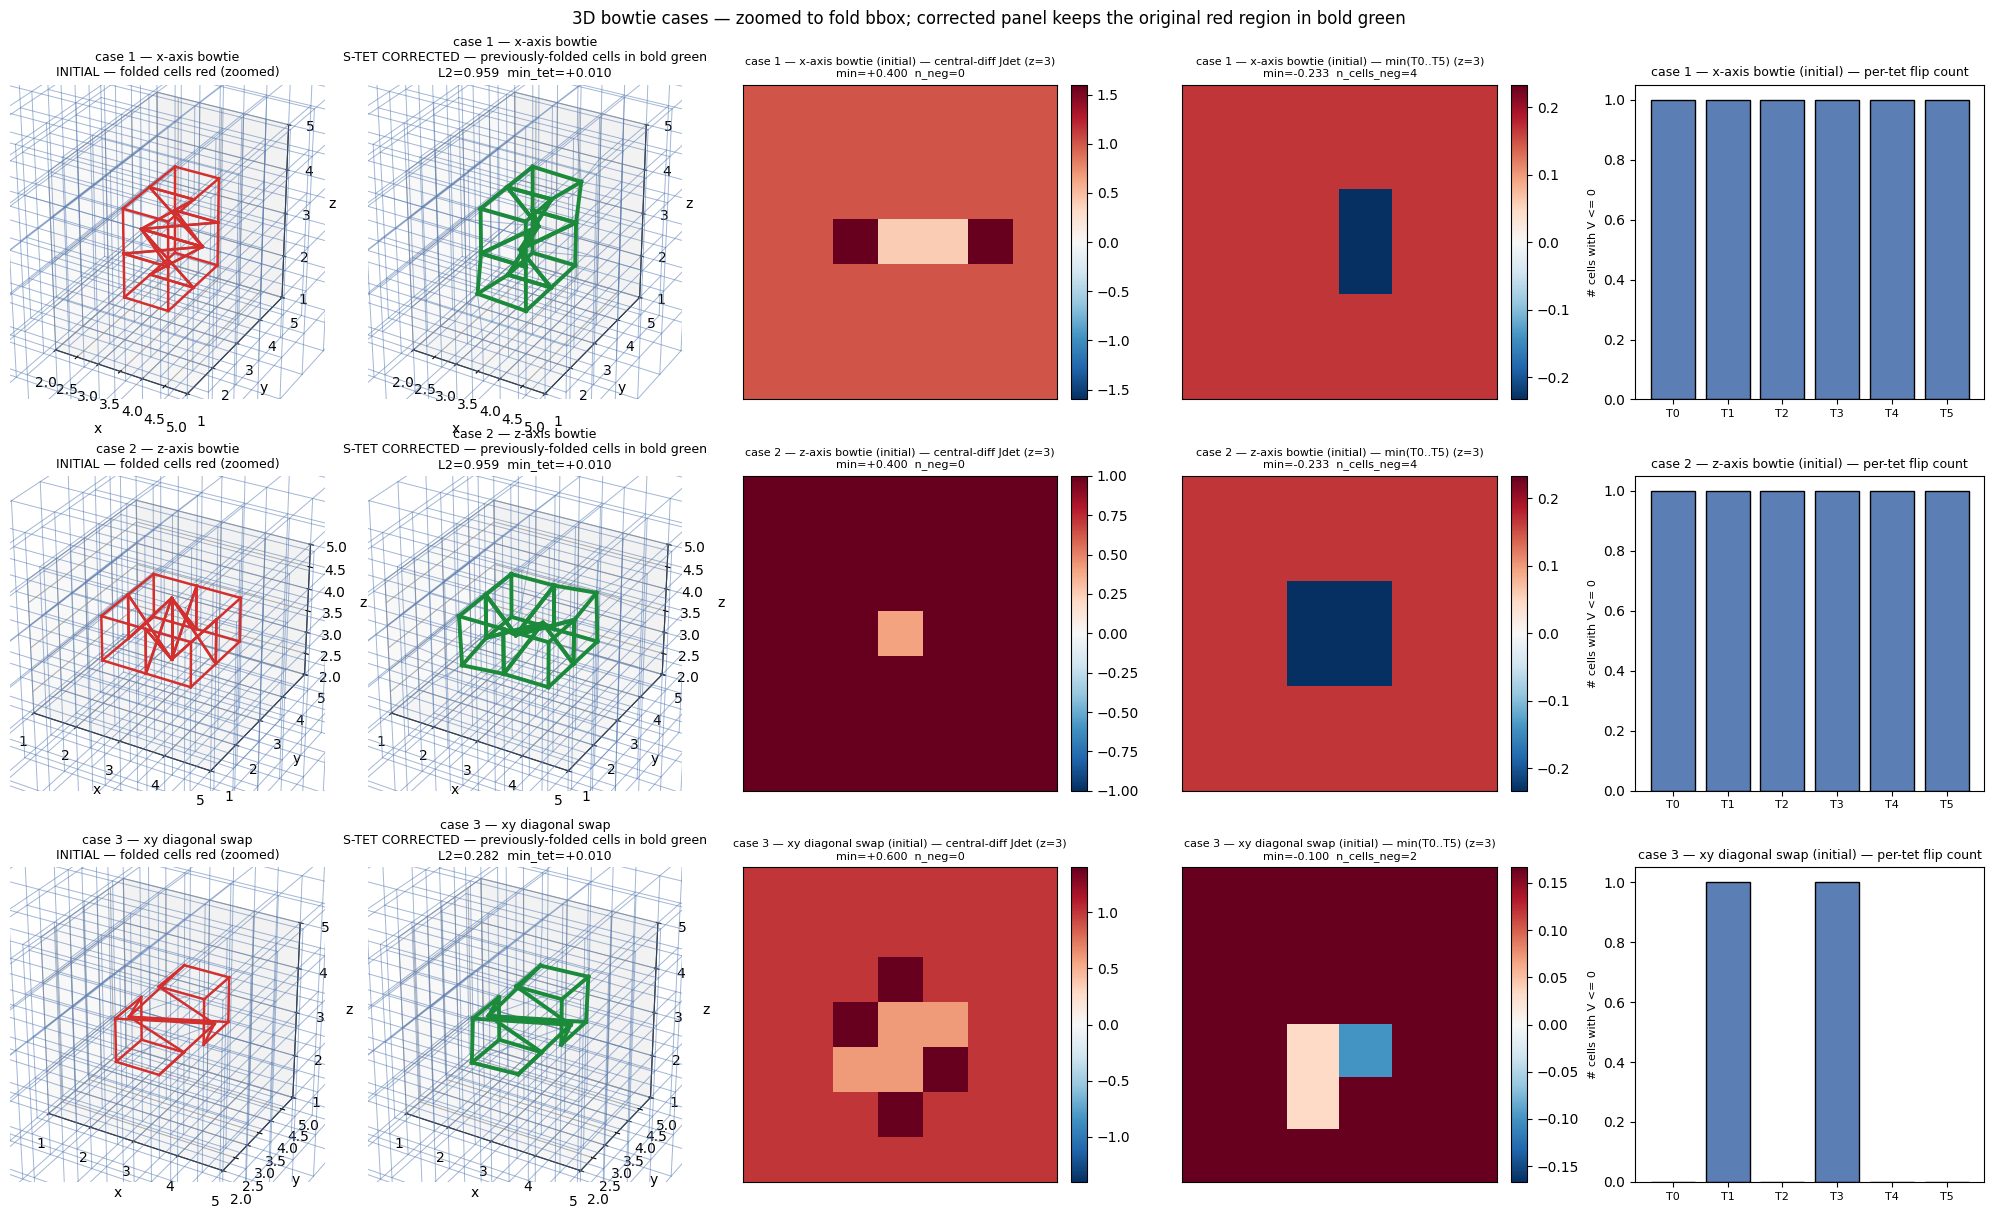

In [16]:
n_cases = len(CASES)
fig = plt.figure(figsize=(20, 4.0 * n_cases), layout='constrained')
gs = fig.add_gridspec(n_cases, 5)

for i, (name, phi) in enumerate(CASES):
    initial_fold_mask = tet_min_per_cell(phi) <= 0

    ax3a = fig.add_subplot(gs[i, 0], projection='3d')
    plot_warped_grid_3d(
        ax3a, phi,
        f'{name}\nINITIAL — folded cells red (zoomed)',
        outline_mask=initial_fold_mask,
        outline_color='#d32f2f',
        outline_lw=1.8,
        zoom_mask=initial_fold_mask,
        zoom_pad=1,
    )

    phi_corr = slsqp_results[name]['tet']['phi']
    r_tet = slsqp_results[name]['tet']
    ax3b = fig.add_subplot(gs[i, 1], projection='3d')
    plot_warped_grid_3d(
        ax3b, phi_corr,
        f'{name}\nS-TET CORRECTED — previously-folded cells in bold green\n'
        f'L2={r_tet["l2"]:.3f}  min_tet={r_tet["min_tet"]:+.3f}',
        outline_mask=initial_fold_mask,
        outline_color='#1b8a3a',
        outline_lw=2.8,
        zoom_mask=initial_fold_mask,
        zoom_pad=1,
    )

    axh1 = fig.add_subplot(gs[i, 2])
    axh2 = fig.add_subplot(gs[i, 3])
    plot_midz_heatmaps([axh1, axh2], phi, name + ' (initial)')

    axb = fig.add_subplot(gs[i, 4])
    plot_per_tet_bars(axb, phi, name + ' (initial)')

plt.suptitle('3D bowtie cases — zoomed to fold bbox; corrected panel keeps the original red region in bold green',
             fontsize=12)
plt.show()

## 2D decomposition — three orthogonal slices through the fold

3D plots of a 3D fold are still hard to read. Here we slice the field along each axis through the centroid of the folded region and plot the resulting 2D warped quad grid (same convention as `01_vs-central-diff.ipynb`'s 2D plots).

For each case, six panels:

- **xy slice** at `z = cz_centroid`: shows the (x, y) projection. Best for the **x-axis bowtie** (the fold lives in this plane).
- **xz slice** at `y = cy_centroid`: shows the (x, z) projection. Best for the **z-axis bowtie**.
- **yz slice** at `x = cx_centroid`: shows the (y, z) projection. Useful for the **xy diagonal swap**.

Each pair (initial / corrected) shares colour conventions:

- **Red 2D quad outline** = a 2D cell in this slice that is the face of a folded 3D cell.
- **Bold green 2D quad outline** on the corrected panel = the *same* 2D cells (i.e. the originally-folded ones), re-drawn after S-TET. They are no longer geometrically inverted in the 2D projection.

Each panel is zoomed to the bounding box of the affected 2D cells + 1-cell padding.

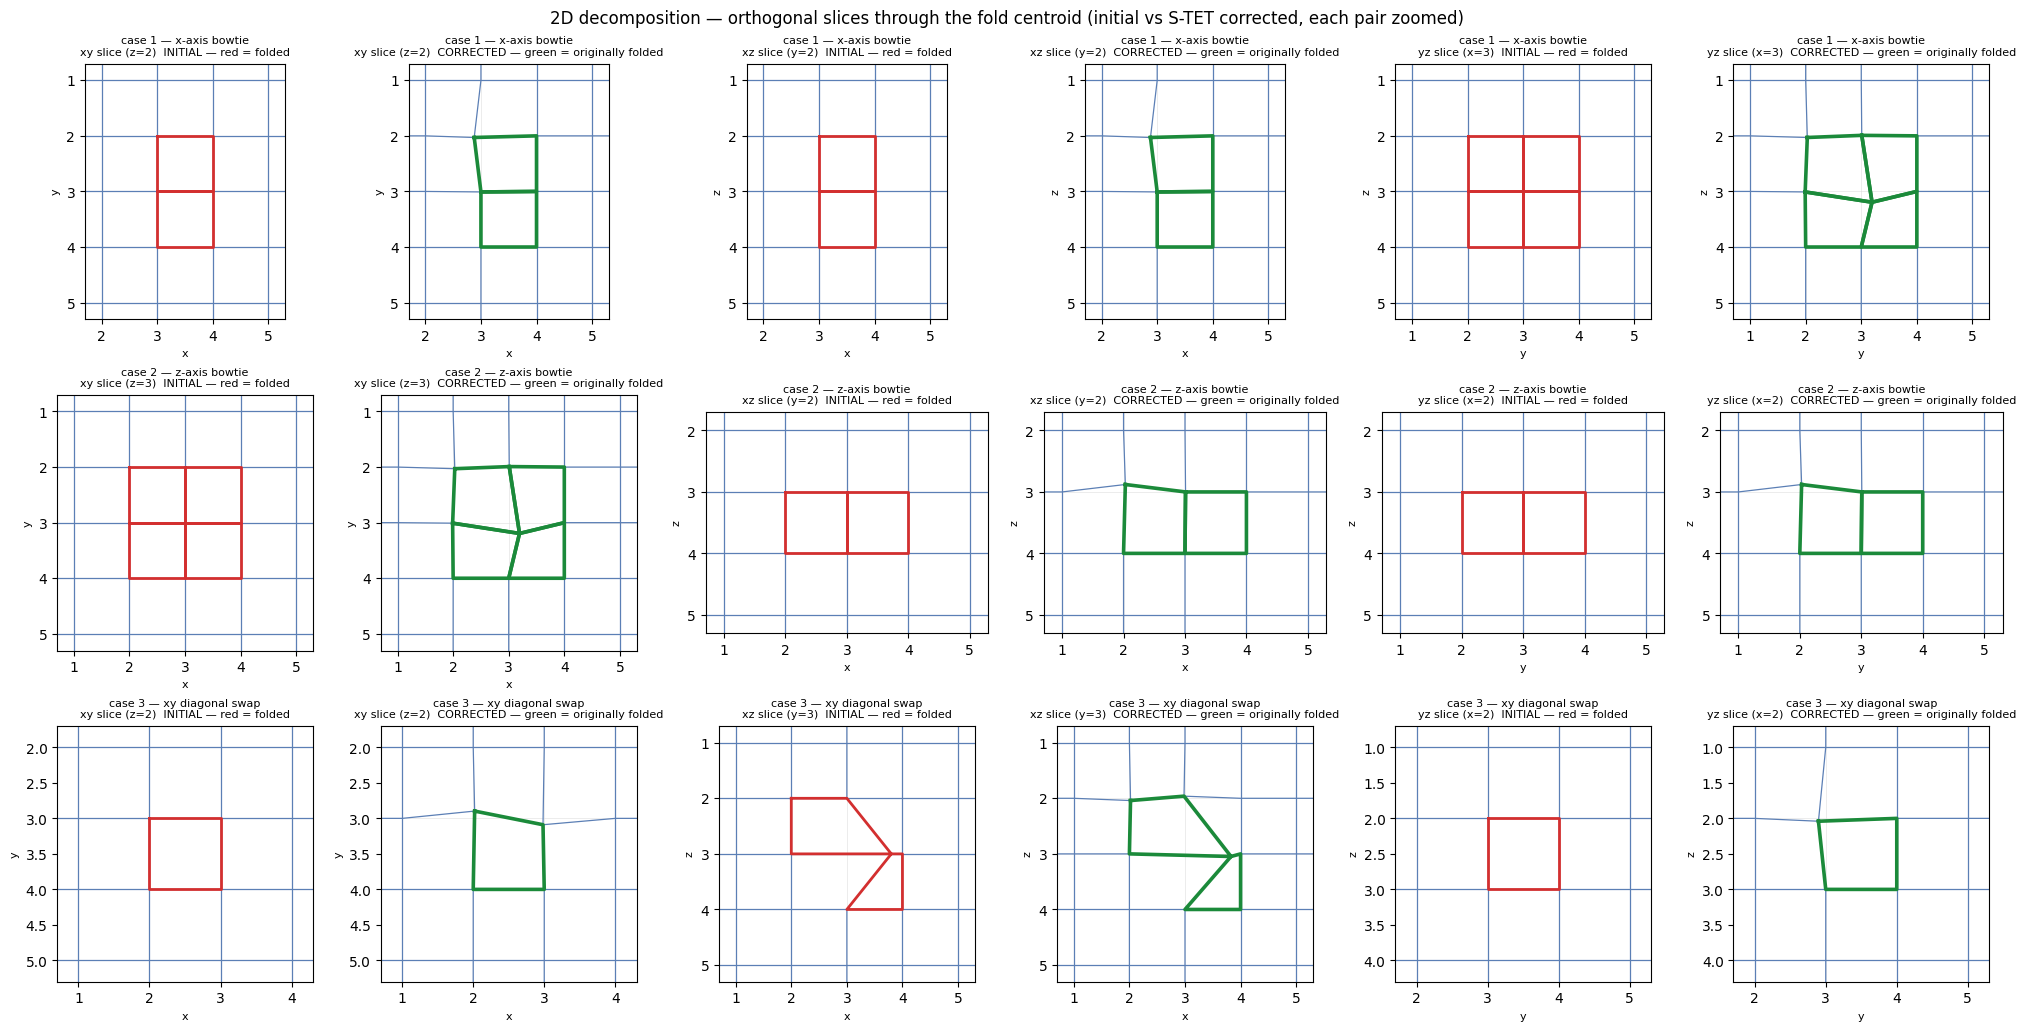

In [17]:
fig, axes = plt.subplots(len(CASES), 6, figsize=(20, 3.4 * len(CASES)),
                          layout='constrained', squeeze=False)
SLICE_AXES = ['xy', 'xz', 'yz']

for i, (name, phi) in enumerate(CASES):
    initial_fold_mask = tet_min_per_cell(phi) <= 0
    phi_corr = slsqp_results[name]['tet']['phi']
    centroid = fold_centroid_3d(initial_fold_mask)
    if centroid is None:
        continue
    cz, cy, cx = centroid
    slice_idx_for = {'xy': cz, 'xz': cy, 'yz': cx}
    fixed_label = {'xy': f'z={cz}', 'xz': f'y={cy}', 'yz': f'x={cx}'}

    for k, axis_name in enumerate(SLICE_AXES):
        si = slice_idx_for[axis_name]
        # Initial — red.
        plot_warped_slice_2d(
            axes[i, 2 * k], phi, axis_name, si,
            outline_mask_3d=initial_fold_mask,
            outline_color='#d32f2f', outline_lw=2.0,
            title=f'{name}\n{axis_name} slice ({fixed_label[axis_name]})  INITIAL — red = folded',
        )
        # Corrected — bold green on the same originally-folded 2D cells.
        plot_warped_slice_2d(
            axes[i, 2 * k + 1], phi_corr, axis_name, si,
            outline_mask_3d=initial_fold_mask,
            outline_color='#1b8a3a', outline_lw=2.6,
            title=f'{name}\n{axis_name} slice ({fixed_label[axis_name]})  CORRECTED — green = originally folded',
        )

plt.suptitle('2D decomposition — orthogonal slices through the fold centroid '
             '(initial vs S-TET corrected, each pair zoomed)', fontsize=12)
plt.show()

## Summary

**Geometry.** A voxel cell decomposes into 6 tets along the body diagonal `v0=(0,0,0) → v7=(1,1,1)`, one per monotone path through cube edges. Per-tet signed volume is a polynomial in `phi`, smooth, and admissible as an SLSQP constraint. Half the path orderings are even permutations of the cube and half odd — the `TET_SIGN_FLIP` vector is calibrated once at startup against the identity field so that valid cells return `V > 0` for all 6 tets.

**Detection.** On all three test cases the 6-tet check flagged at least one cell where central-difference Jdet did not. The disagreement is the same pathology as in 2D (`01_vs-central-diff.ipynb`): the 2Δ central-difference stencil averages partial derivatives over neighbours so that opposing-sign contributions cancel. The local triangulation can't average — it sees the swap directly.

**Correction.** The S-TET solver consistently produced fields with `min_tet ≥ THRESHOLD` on cases where S-CD terminated thinking the field was clean while at least one tet was still flipped. S-CD typically finishes in `nit=1` (the central-diff Jdet was already ≥ THRESHOLD before optimisation — there was nothing for the CD-constrained solver to do).

**Cost.** On a 7³ grid with 3 channels (1029 variables) the 6-tet constraint vector has length `6 · 6³ = 1296`. SLSQP wall time per case was on the order of seconds — comparable to S-CD. Larger grids will need either the windowed iterative pattern from `dvfopt.core.iterative3d` or a sparse Jacobian for the constraint (analog of `gradients3d.jdet_constraint_jacobian_3d` for tets).

**Next steps (out of scope for this notebook):**
- Promote the helpers in this notebook into `dvfopt/jacobian/tetrahedron_sign.py` mirroring `triangle_sign.py`.
- Add tet-volume constraint mode to `iterative_3d` (currently only central-diff Jdet is supported in 3D, per `CLAUDE.md`).
- Analytic constraint Jacobian for the 6-tet form for SLSQP scaling to larger volumes.
- 24-tet Kuhn split as the analog of `triangle_det2D` (4 triangles per cell).